# Futures/Spot HBT Step-by-Step Runner

The notebook is intentionally thin. Configuration, pipeline stages, report tables, and plotting live in separate Python scripts in this folder. Both this notebook and `run_full_backtest.py` save CSV reports and PNG figures.

In [ ]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
TEST_ROOT = CURRENT_DIR if (CURRENT_DIR / 'backtest_config.py').exists() else CURRENT_DIR / 'future_spot' / 'test'
if not TEST_ROOT.exists():
    raise FileNotFoundError('Open this notebook from future_spot/test or the repository root')
PROJECT_ROOT = TEST_ROOT.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
for path in (TEST_ROOT, PROJECT_ROOT, WORKSPACE_ROOT, PROJECT_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from IPython.display import Image, display
from backtest_config import default_notebook_args
from backtest_pipeline import run_backtest_pipeline
from report_tables import build_report_tables
from report_plots import save_report_plots

## 1. Parameters

In [ ]:
args = default_notebook_args(
    start_date='2026-07-01',
    end_date='2026-07-31',
    order_latency_ms=10.0,
    continue_on_error=True,
    response_latency_ms=10.0,
    feed_latency_offset_ms=10.0,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=True,
)
args.output_dir

PosixPath('/home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260131_latency_10ms')

## 2. Full Backtest and Core CSV Outputs

In [ ]:
artifacts = run_backtest_pipeline(args)
display(artifacts.frame('summary').head(20))
display(artifacts.frame('entry_exit_index').head(20))

row_indexes for symbol=1303: {'history.parquet': (6513686, 280627)}
input_rows=280207
converted_rows=280207
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=0
raw_events=3397171
output_events=3397171
depth_events=3356652
trade_events=40519
opening_jump_qty=0.0
first_exch_ts=1767834001448116000
last_exch_ts=1767849899995295000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_ask_mismatches=0
trade_qty_mismatches=0
load_seconds=1.876318
event_build_seconds=0.507003
normalize_seconds=0.210861
write_seconds=1.840868
output=/home/zoufuc/hftbacktest/data/tw_stock_events/1303_20260108_090000_132500.npz
input_rows=213015
converted_rows=213015
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=0
raw_events=2563310
output_events=2563310
depth_events=2556180
trade_events=7130
opening_jump_qty=0.0
first_exch_ts=1767834000090000000
last_exch_ts=1767849898095000000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatc

,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,step_ns,second_leg_delay_ns,post_first_feed_wait,post_first_feed_timeout_ns,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns,strategy_engine,scan_calls,python_decisions
0,2026-01-08,2026-01-08::1303_CAFA6,1303_CAFA6,1303,CAFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
1,2026-01-08,2026-01-08::2002_CBFA6,2002_CBFA6,2002,CBFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
2,2026-01-08,2026-01-08::1301_CFFA6,1301_CFFA6,1301,CFFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
3,2026-01-08,2026-01-08::2409_CHFA6,2409_CHFA6,2409,CHFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
4,2026-01-08,2026-01-08::1605_CSFA6,1605_CSFA6,1605,CSFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
5,2026-01-08,2026-01-08::2408_CYFA6,2408_CYFA6,2408,CYFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
6,2026-01-08,2026-01-08::2603_CZFA6,2603_CZFA6,2603,CZFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
7,2026-01-08,2026-01-08::2609_DAFA6,2609_DAFA6,2609,DAFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
8,2026-01-08,2026-01-08::1101_DFFA6,1101_DFFA6,1101,DFFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
9,2026-01-08,2026-01-08::1326_DGFA6,1326_DGFA6,1326,DGFA6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264


,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-01-08,2026-01-08::1303_CAFA6,1303_CAFA6,0,0,0,0
1,2026-01-08,2026-01-08::2002_CBFA6,2002_CBFA6,0,0,0,0
2,2026-01-08,2026-01-08::1301_CFFA6,1301_CFFA6,0,0,0,0
3,2026-01-08,2026-01-08::2409_CHFA6,2409_CHFA6,0,0,0,0
4,2026-01-08,2026-01-08::1605_CSFA6,1605_CSFA6,0,0,0,0
5,2026-01-08,2026-01-08::2408_CYFA6,2408_CYFA6,0,0,0,0
6,2026-01-08,2026-01-08::2603_CZFA6,2603_CZFA6,0,0,0,0
7,2026-01-08,2026-01-08::2609_DAFA6,2609_DAFA6,0,0,0,0
8,2026-01-08,2026-01-08::1101_DFFA6,1101_DFFA6,0,0,0,0
9,2026-01-08,2026-01-08::1326_DGFA6,1326_DGFA6,0,0,0,0


## 3. Analysis CSV Outputs

In [ ]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('roi_summary_including_open'))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,2408,7,2,35029.6100,5004.230000,40,0,0,0.0
1,2337,7,2,29325.5000,4189.357143,23,0,0,1.0
2,2481,10,2,24222.0650,2422.206500,50,0,0,10.0
3,1605,17,2,19332.7422,1137.220129,53,0,0,7.0
4,6770,7,2,11973.5680,1710.509714,20,0,0,0.0
5,3189,11,2,8501.7310,772.884636,20,0,0,0.0
6,6282,17,2,7272.8263,427.813312,31,1,0,9.0
7,1504,11,2,6547.2788,595.207164,8,0,0,0.0
8,2367,16,2,4132.4550,258.278438,20,0,0,0.0
9,3006,5,1,3522.9060,704.581200,4,0,0,0.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,1,1,21,1,1,0.0


,entry_cash_out,net_stock_cash_stuck,realized_pnl,open_locked_pnl,total_pnl_including_open,total_roi_on_entry_cash_pct,open_roi_on_stuck_cash_pct,open_pairs
0,3.208240e+07,3.438189e+06,152711.4106,41393.51,194104.9206,0.00605,0.012039,27.0


Report CSV directory: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260131_latency_10ms/reports


## 4. Saved PNG Outputs

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260131_latency_10ms/figures/performance_overview.png


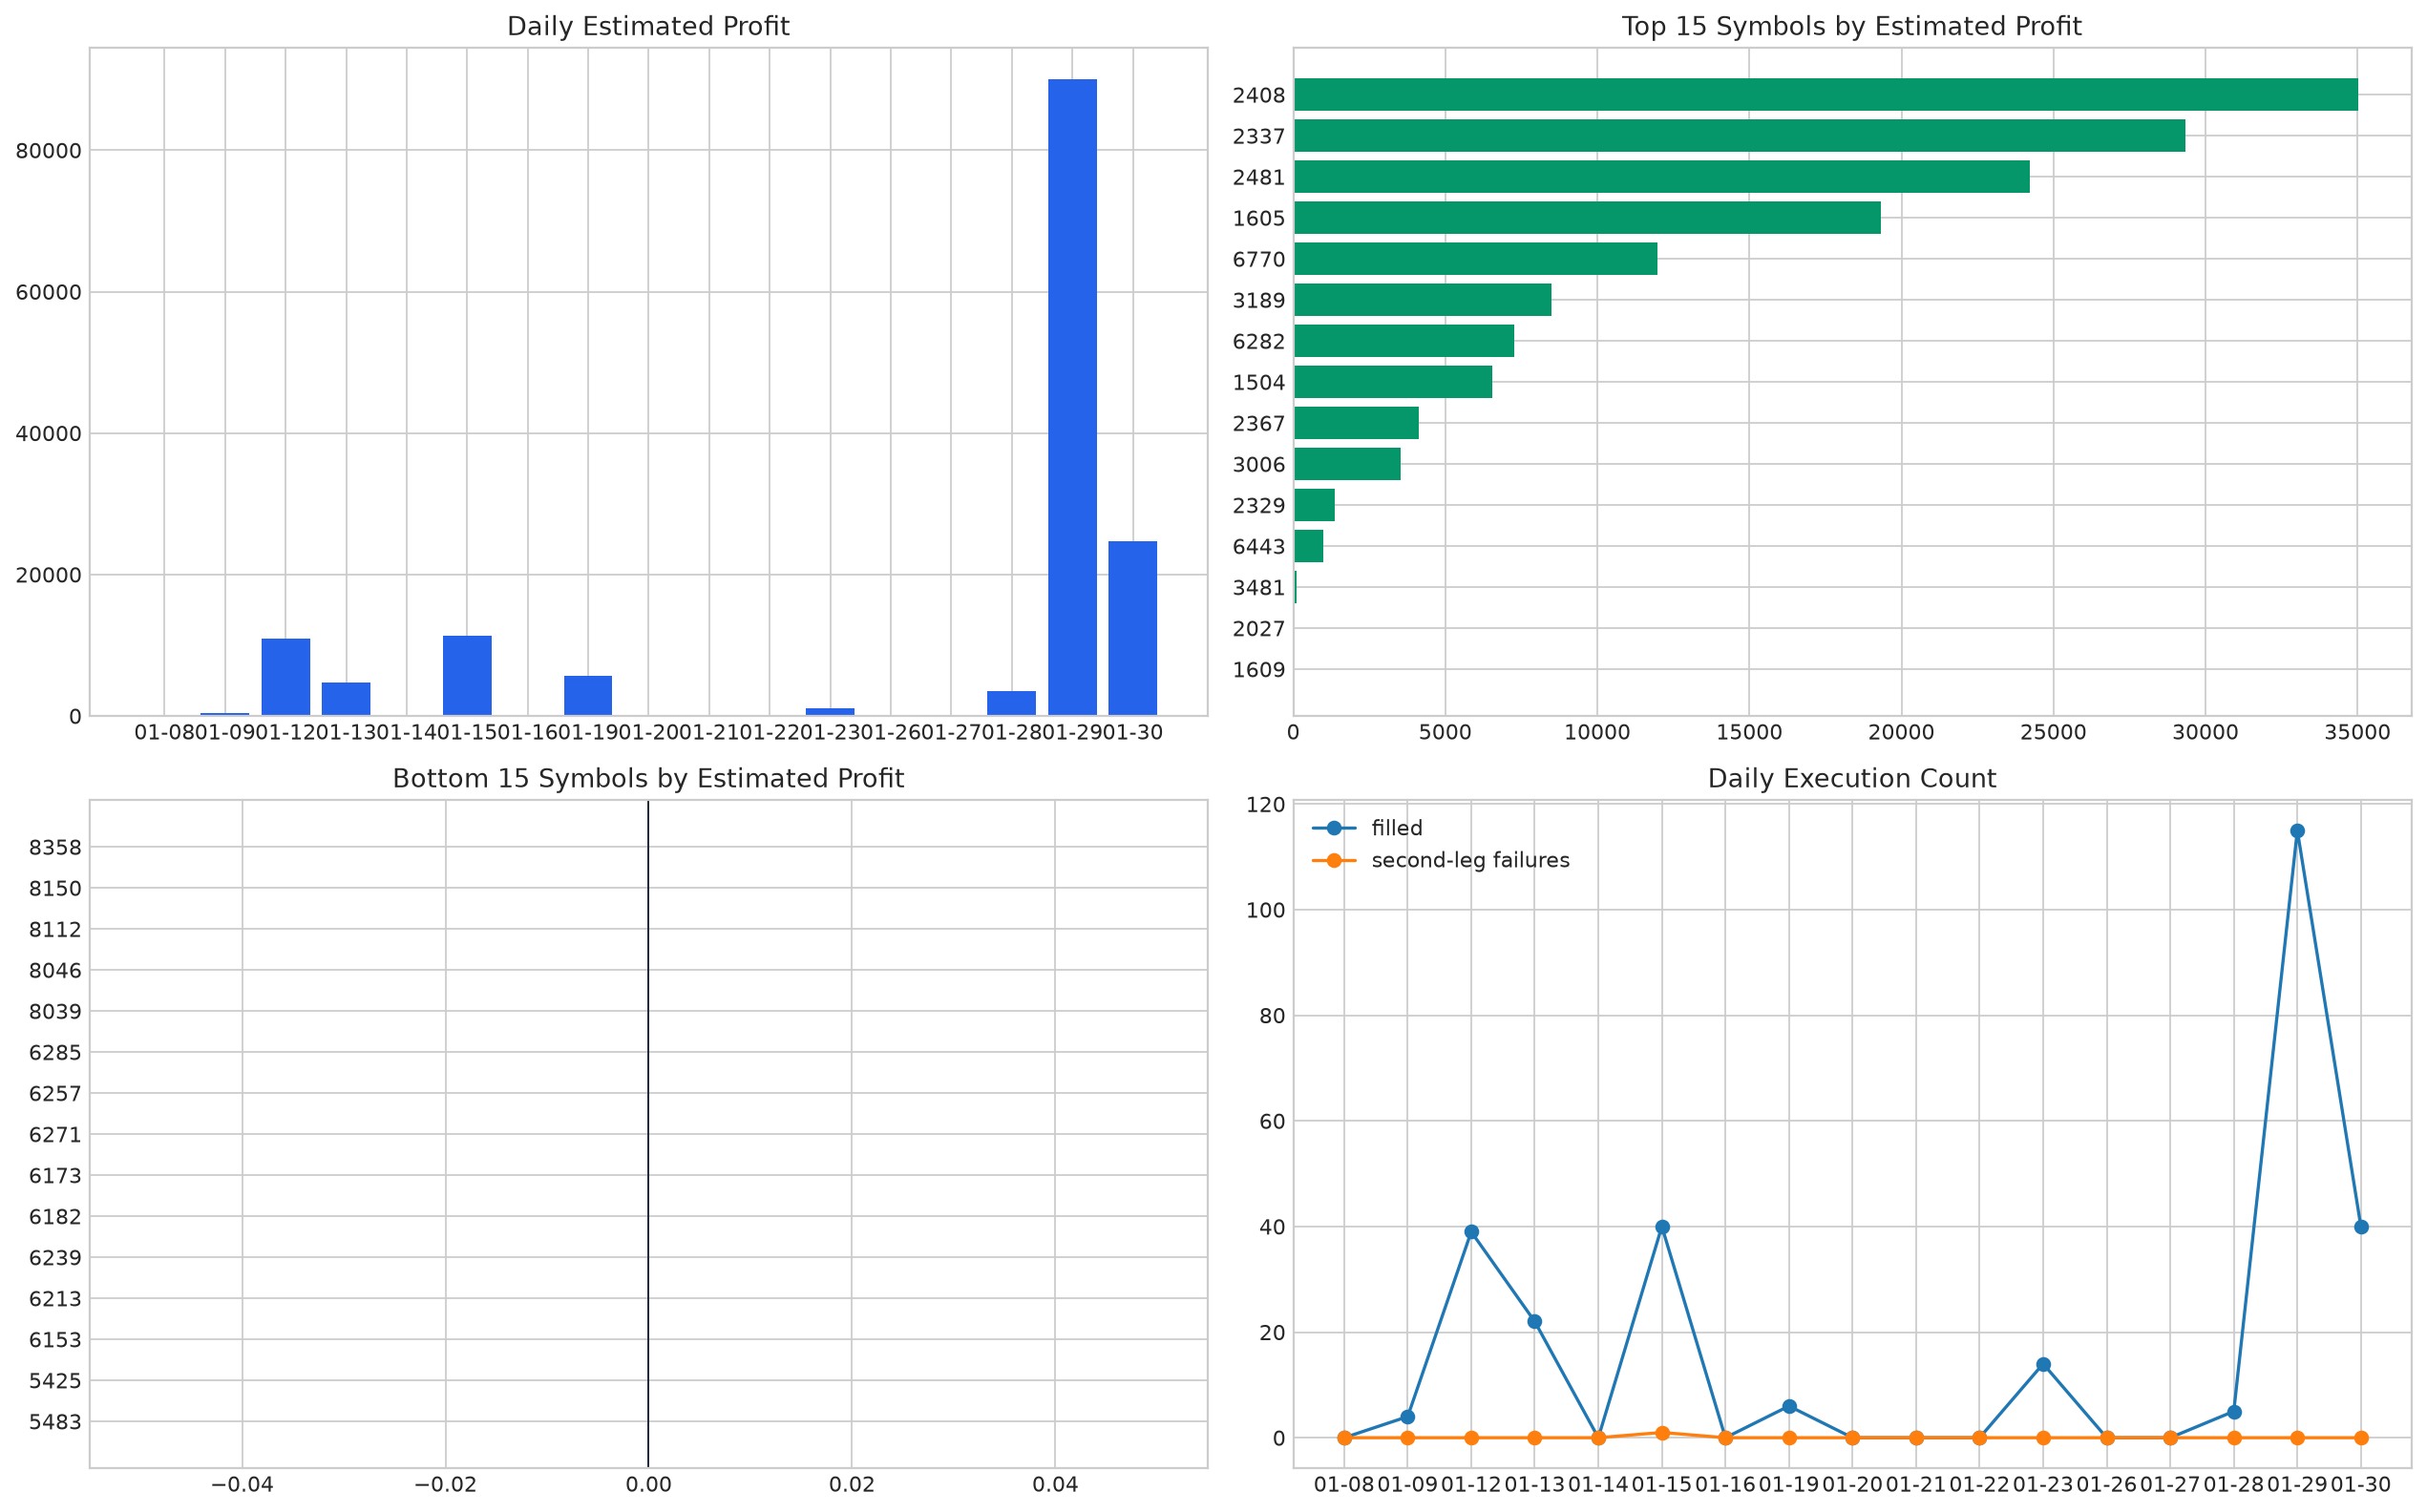

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260131_latency_10ms/figures/pair_profit_scatter.png


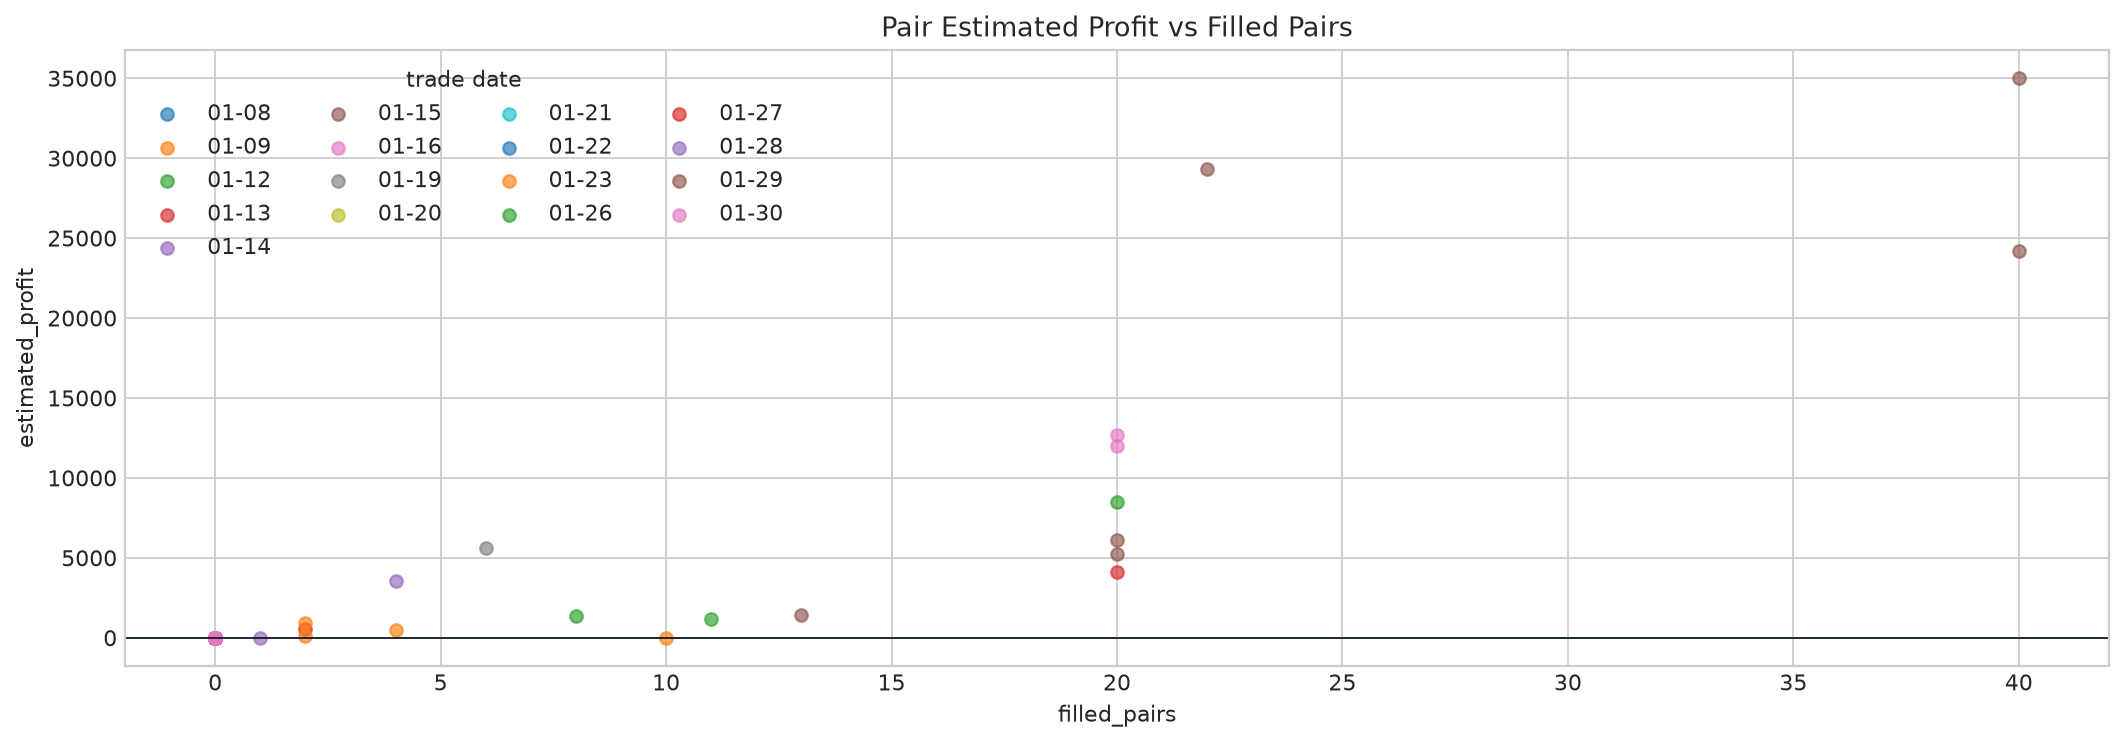

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260131_latency_10ms/figures/stuck_cash.png


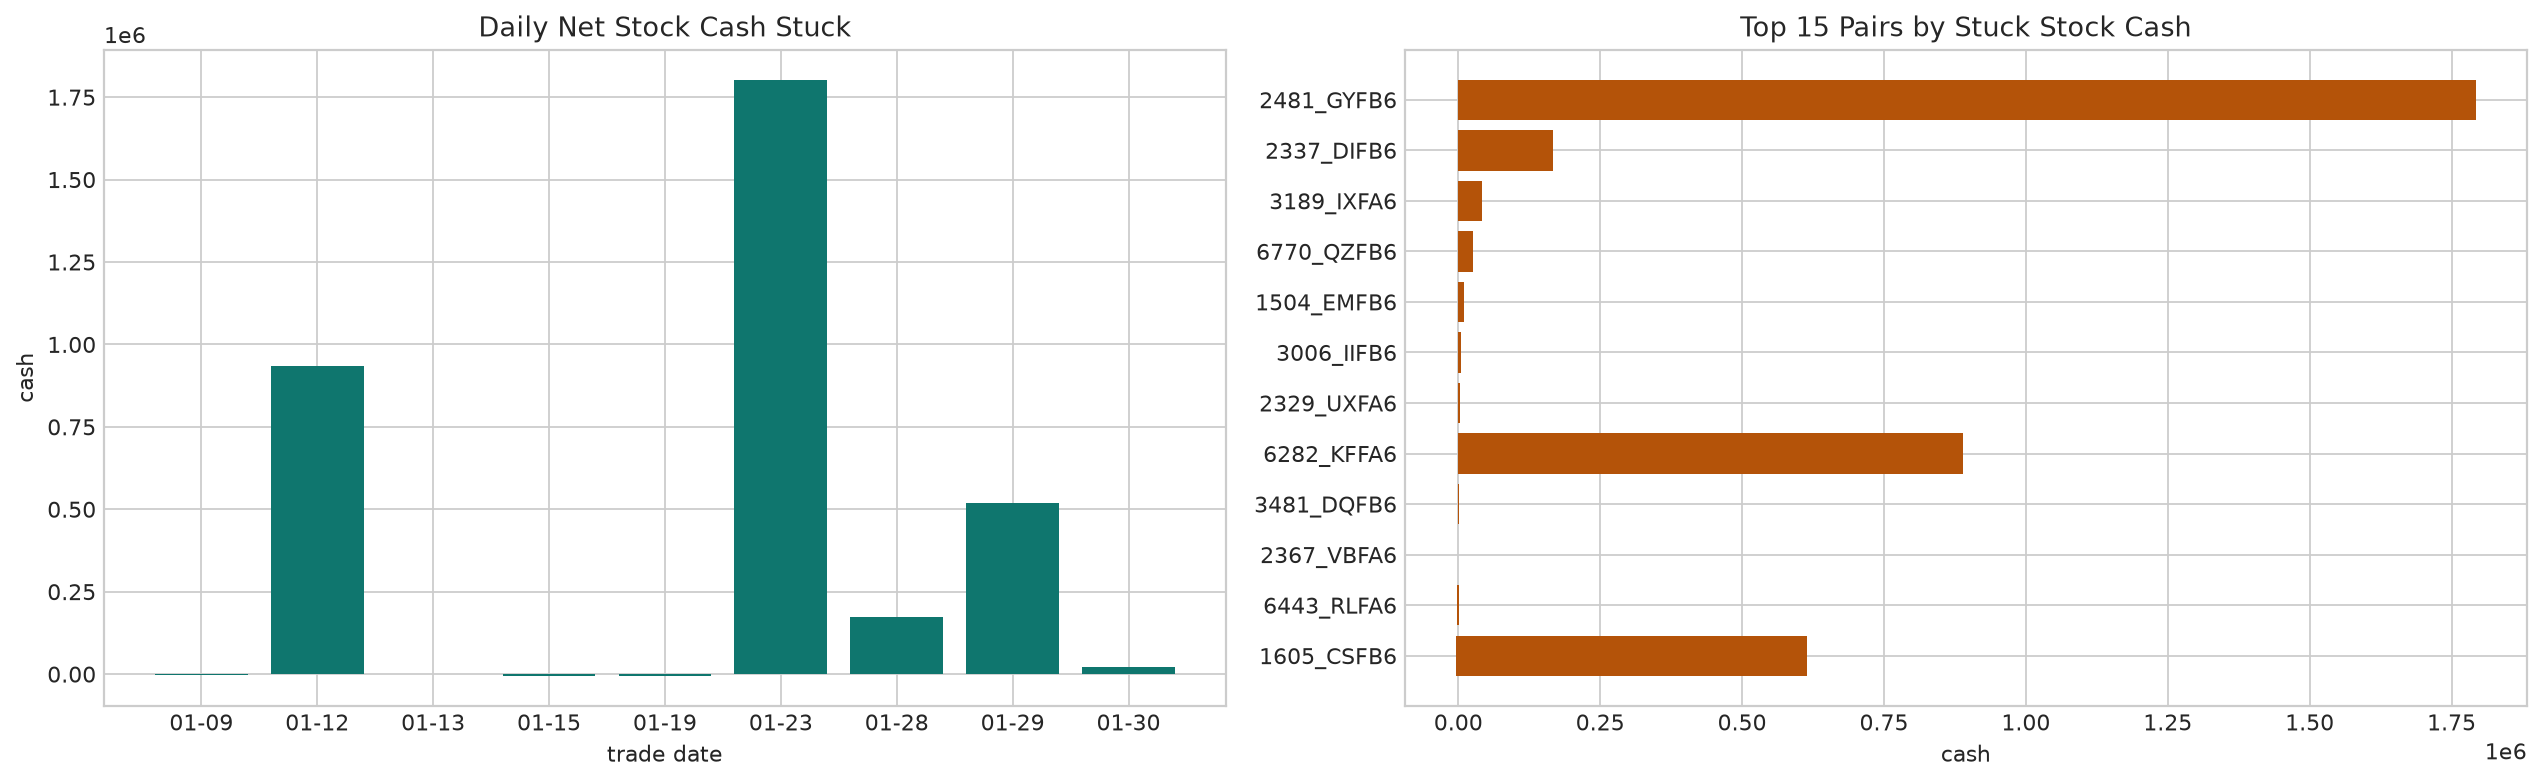

roi_including_open: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260131_latency_10ms/figures/roi_including_open.png


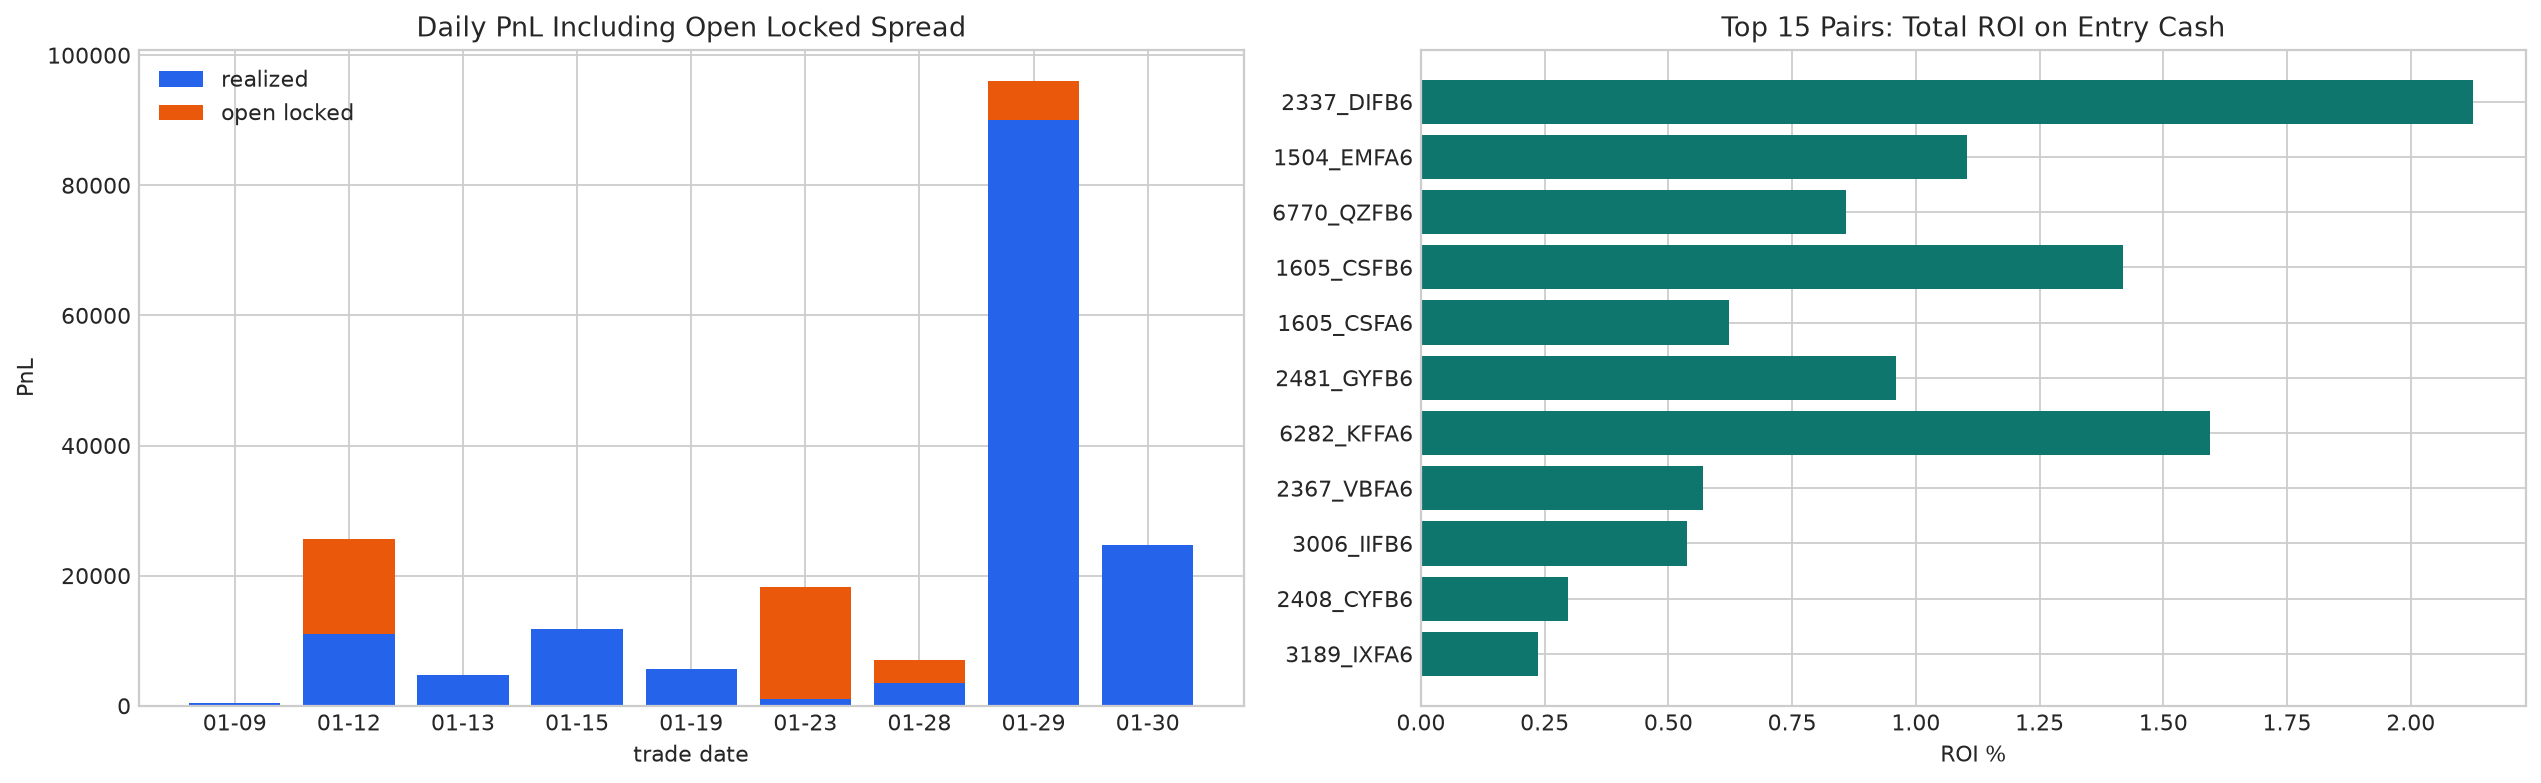

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260131_latency_10ms/figures/latency_timelines.png


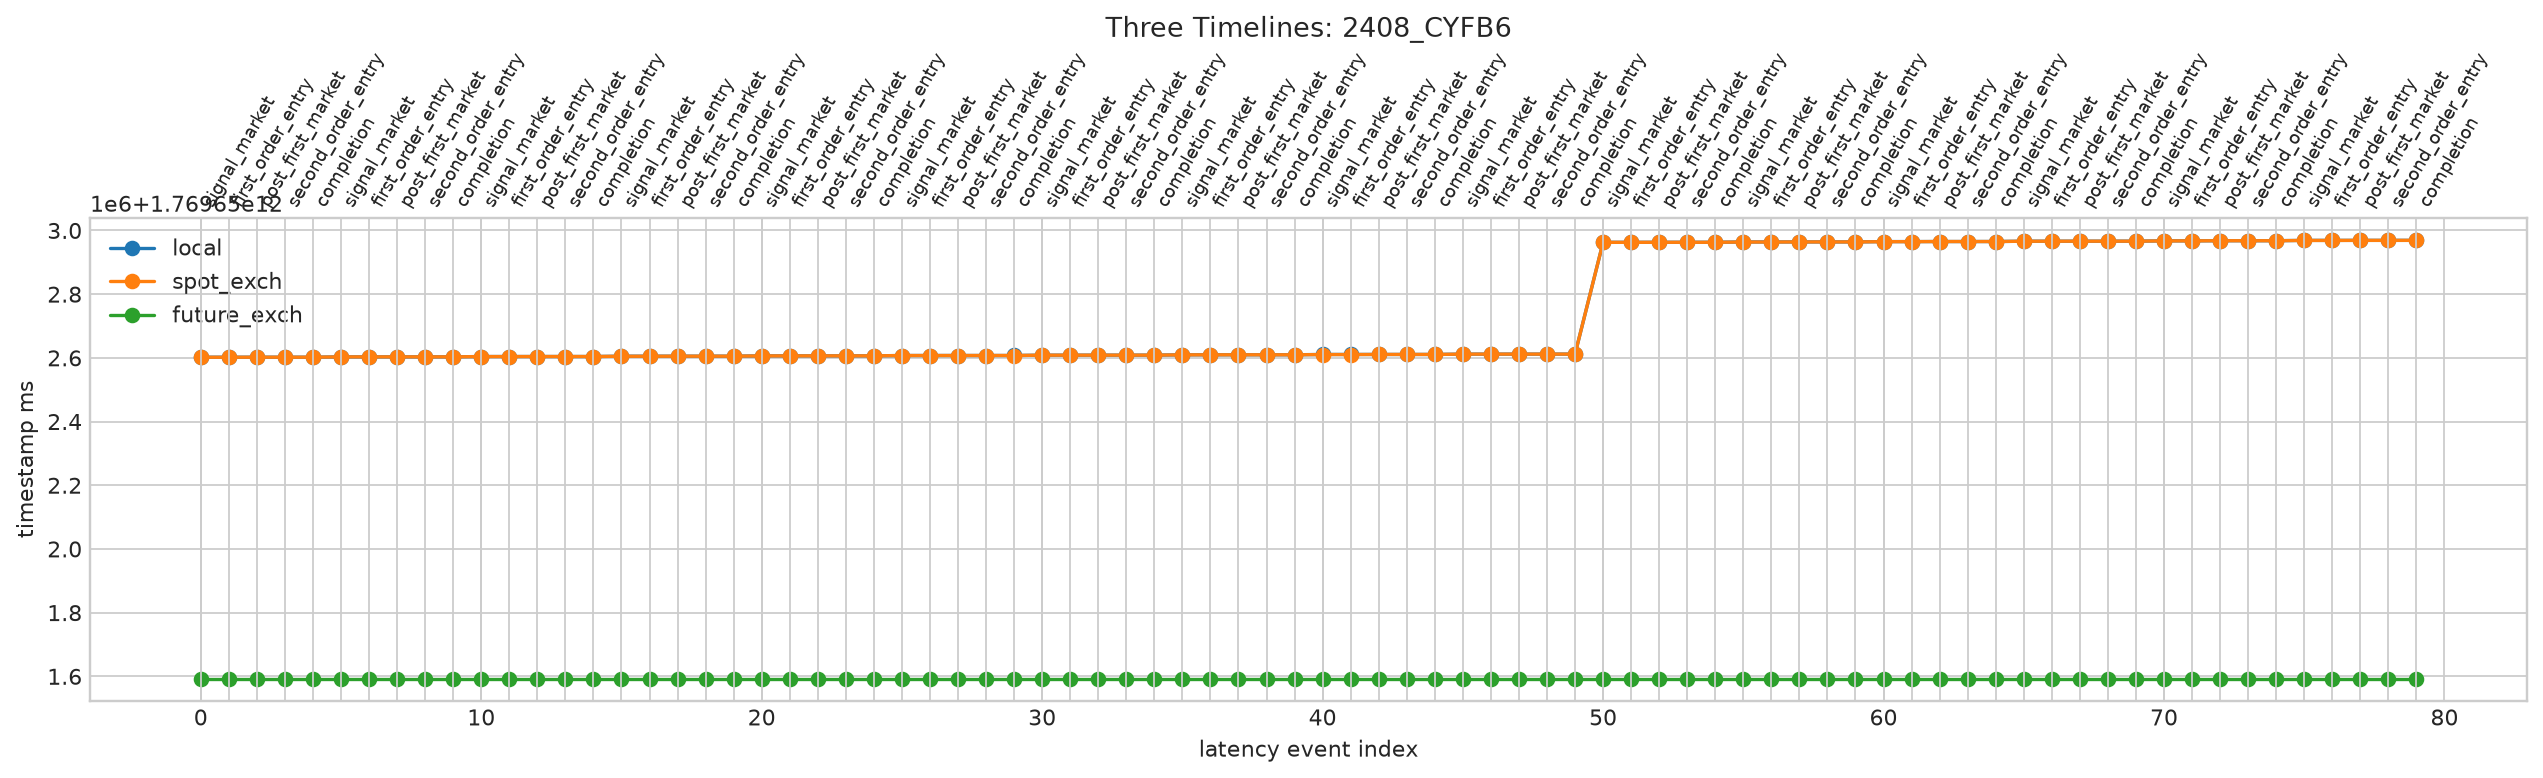

In [ ]:
figure_paths = save_report_plots(artifacts, reports)
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## 5. Optional Drill-down

In [ ]:
selected_pair = reports.selected_pair
entry_exit = artifacts.frame('entry_exit_all')
latency = artifacts.frame('latency')
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    if 'pair_name' in entry_exit.columns:
        display(entry_exit.loc[entry_exit['pair_name'].eq(selected_pair)].head(100))
    if 'pair_name' in latency.columns:
        display(latency.loc[latency['pair_name'].eq(selected_pair)].head(120))

,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
3068,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 10:10:02.020000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,291.0,291.5,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3069,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 10:10:02.090000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,291.0,291.5,NaN,...,sell,295.5,295.5,1.0,stock,buy,292.5,291.5,2.0,49.999872
3070,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 10:10:03.090000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,291.0,291.5,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3071,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 10:10:03.170000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,291.0,291.5,NaN,...,sell,295.5,295.5,1.0,stock,buy,292.5,291.5,2.0,60.000000
3072,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 10:10:04.170000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,291.0,291.5,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 12:27:19.600000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,296.0,296.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3164,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 12:27:20.600000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,296.0,296.5,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3165,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 12:27:20.600000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,296.0,296.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3166,2026-01-29,2026-01-29::2408_CYFB6,2026-01-29 12:27:21.600000+08:00,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,296.0,296.5,46.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
723,2026-01-29,2026-01-29::2408_CYFB6,1769652602020000000,4202,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1769651592126000000,1769651592136000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-01-29 10:10:02.020000+08:00
724,2026-01-29,2026-01-29::2408_CYFB6,1769652602040000000,4202,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1769651592126000000,1769651592136000000,10000000,1.769653e+18,1.769653e+18,1.769653e+18,10000000.0,10000000.0,2026-01-29 10:10:02.020000+08:00
725,2026-01-29,2026-01-29::2408_CYFB6,1769652602070000000,4202,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1769651592126000000,1769651592136000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-01-29 10:10:02.070000+08:00
726,2026-01-29,2026-01-29::2408_CYFB6,1769652602090000000,4202,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1769651592126000000,1769651592136000000,10000000,1.769653e+18,1.769653e+18,1.769653e+18,10000000.0,10000000.0,2026-01-29 10:10:02.070000+08:00
727,2026-01-29,2026-01-29::2408_CYFB6,1769652602090000000,4202,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,None,...,10000000,1769651592126000000,1769651592136000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-01-29 10:10:02.090000+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,2026-01-29,2026-01-29::2408_CYFB6,1769660828020000000,12425,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1769658803278000000,1769658803288000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-01-29 12:27:08.020000+08:00
839,2026-01-29,2026-01-29::2408_CYFB6,1769660828040000000,12425,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1769658803278000000,1769658803288000000,10000000,1.769661e+18,1.769661e+18,1.769661e+18,10000000.0,10000000.0,2026-01-29 12:27:08.020000+08:00
840,2026-01-29,2026-01-29::2408_CYFB6,1769660828820000000,12425,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1769658803278000000,1769658803288000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-01-29 12:27:08.820000+08:00
841,2026-01-29,2026-01-29::2408_CYFB6,1769660828840000000,12425,2408_CYFB6,2408,CYFB6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1769658803278000000,1769658803288000000,10000000,1.769661e+18,1.769661e+18,1.769661e+18,10000000.0,10000000.0,2026-01-29 12:27:08.820000+08:00
